# Chapitre 6 — Analyse exploratoire (EDA) et visualisation

**Cours : Analyse et traitement des données** · Auteur : *Issa Gueye*

## Objectifs

- Conduire une **analyse exploratoire** structurée : univariée → bivariée → multivariée.
- Choisir le **bon graphique** selon le type des variables.
- Calculer et interpréter **corrélations** (Pearson, Spearman) — et connaître leurs pièges.
- Produire des graphiques **lisibles, honnêtes et accessibles**.

> « Le graphique le plus simple qui répond à la question est le meilleur. »
> L'EDA (Tukey, 1977) consiste à **regarder** les données avant de les modéliser.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA = next(p for p in [Path("data/brutes"), Path("../data/brutes"), Path("../../data/brutes")] if p.exists())
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")   # palette accessible daltoniens

menages = pd.read_csv(DATA / "enquete_menages.csv")
menages.loc[menages["taille_menage"] == 99, "taille_menage"] = np.nan
ordre_educ = ["Aucun", "Coranique", "Primaire", "Secondaire", "Supérieur"]
menages["education_chef"] = pd.Categorical(menages["education_chef"], ordre_educ, ordered=True)
menages["log10_revenu"] = np.log10(menages["revenu_mensuel_fcfa"])

## 1. Quel graphique pour quelles variables ?

| Variables | Question | Graphique |
|---|---|---|
| 1 quantitative | distribution ? | histogramme, densité (KDE), boîte, ECDF |
| 1 qualitative | répartition ? | diagramme en barres (éviter les camemberts à > 3 parts) |
| quanti × quanti | relation ? | nuage de points (+ tendance), hexbin si beaucoup de points |
| quanti × quali | comparaison de groupes ? | boîtes, violons, *strip/swarm*, barres d'erreur |
| quali × quali | association ? | barres empilées à 100 %, carte de chaleur d'un tableau croisé |
| temps × quanti | évolution ? | courbe |
| plusieurs quanti | structure ? | matrice de corrélation, *pairplot*, ACP (chap. 9) |

## 2. Analyse univariée

### 2.1 Variable quantitative : forme de la distribution

In [2]:
rev = menages["revenu_mensuel_fcfa"].dropna()
resume = pd.Series({
    "n": rev.size, "moyenne": rev.mean(), "médiane": rev.median(), "écart-type": rev.std(),
    "CV (%)": 100 * rev.std() / rev.mean(), "Q1": rev.quantile(.25), "Q3": rev.quantile(.75),
    "asymétrie (skew)": rev.skew(), "aplatissement (kurtosis)": rev.kurt(),
})
resume.round(2)

n                             2646.00
moyenne                     280012.47
médiane                     214000.00
écart-type                  222945.49
CV (%)                          79.62
Q1                          137250.00
Q3                          349000.00
asymétrie (skew)                 2.82
aplatissement (kurtosis)        14.43
dtype: float64

- **Moyenne > médiane** et **asymétrie > 0** : distribution étalée à droite (quelques hauts revenus).
- Dans ce cas, la **médiane** décrit mieux le « ménage typique ».

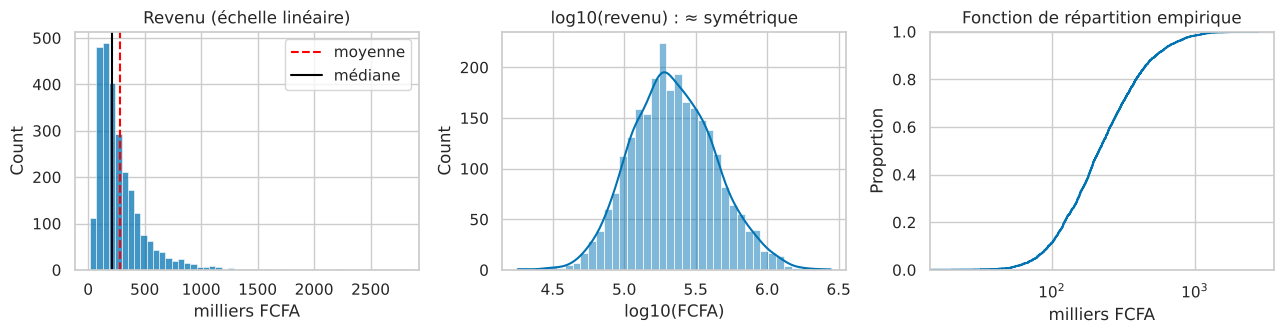

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
sns.histplot(rev / 1000, bins=50, ax=axes[0])
axes[0].axvline(rev.mean() / 1000, color="red", ls="--", label="moyenne")
axes[0].axvline(rev.median() / 1000, color="black", label="médiane")
axes[0].set(title="Revenu (échelle linéaire)", xlabel="milliers FCFA"); axes[0].legend()
sns.histplot(menages["log10_revenu"], bins=40, kde=True, ax=axes[1])
axes[1].set(title="log10(revenu) : ≈ symétrique", xlabel="log10(FCFA)")
sns.ecdfplot(rev / 1000, ax=axes[2])
axes[2].set(title="Fonction de répartition empirique", xlabel="milliers FCFA", xscale="log")
plt.tight_layout(); plt.show()

> ⚠️ Le **nombre de classes** d'un histogramme change la lecture. Essayer plusieurs valeurs
> (règles de Sturges, Freedman–Diaconis : `bins="fd"`). L'**ECDF** n'a pas ce paramètre.

### 2.2 Variable qualitative

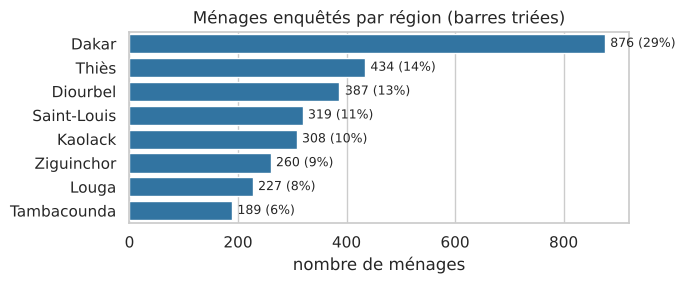

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
comptes = menages["region"].value_counts()
sns.barplot(x=comptes.values, y=comptes.index, ax=ax, color="tab:blue")
for i, v in enumerate(comptes.values):
    ax.text(v + 10, i, f"{v} ({v / comptes.sum():.0%})", va="center", fontsize=9)
ax.set(xlabel="nombre de ménages", ylabel="", title="Ménages enquêtés par région (barres triées)")
plt.tight_layout(); plt.show()

## 3. Analyse bivariée

### 3.1 Quantitative × qualitative

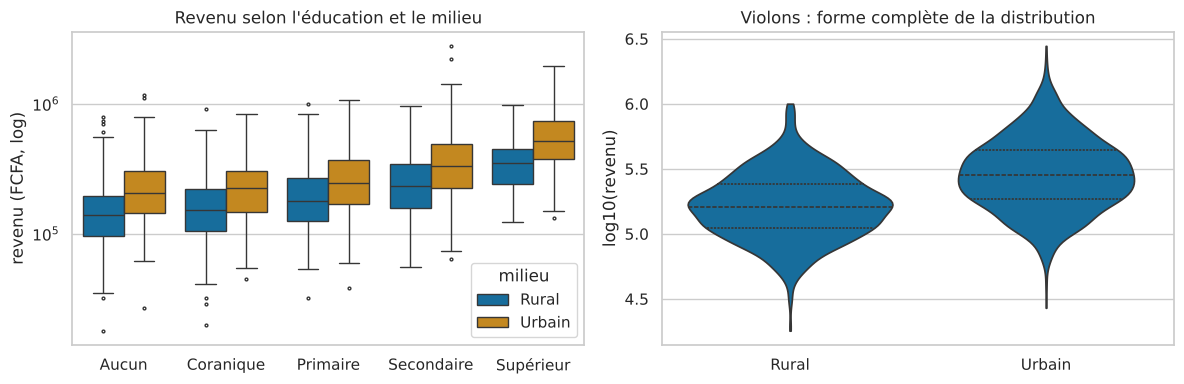

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=menages, x="education_chef", y="revenu_mensuel_fcfa", hue="milieu", ax=axes[0],
            log_scale=True, fliersize=2)
axes[0].set(title="Revenu selon l'éducation et le milieu", xlabel="", ylabel="revenu (FCFA, log)")
sns.violinplot(data=menages, x="milieu", y="log10_revenu", inner="quart", ax=axes[1], cut=0)
axes[1].set(title="Violons : forme complète de la distribution", xlabel="", ylabel="log10(revenu)")
plt.tight_layout(); plt.show()

**Lire une boîte à moustaches** : trait central = médiane ; boîte = Q1–Q3 (50 % central) ;
moustaches = jusqu'à 1,5 × IQR ; points = valeurs au-delà.

### 3.2 Quantitative × quantitative

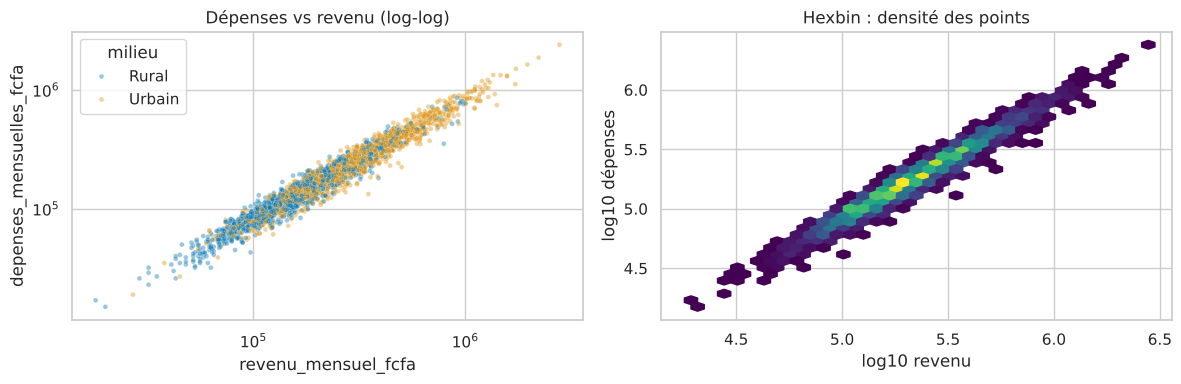

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=menages, x="revenu_mensuel_fcfa", y="depenses_mensuelles_fcfa", hue="milieu",
                alpha=0.4, s=12, ax=axes[0])
axes[0].set(xscale="log", yscale="log", title="Dépenses vs revenu (log-log)")
axes[1].hexbin(menages["log10_revenu"], np.log10(menages["depenses_mensuelles_fcfa"]), gridsize=35, cmap="viridis",
               mincnt=1)
axes[1].set(title="Hexbin : densité des points", xlabel="log10 revenu", ylabel="log10 dépenses")
plt.tight_layout(); plt.show()

### 3.3 Corrélations

| Coefficient | Mesure | Sensible aux extrêmes ? |
|---|---|---|
| **Pearson** $r$ | relation **linéaire** | oui |
| **Spearman** $\rho$ | relation **monotone** (corrélation des rangs) | peu |
| **Kendall** $\tau$ | concordance des paires | peu |

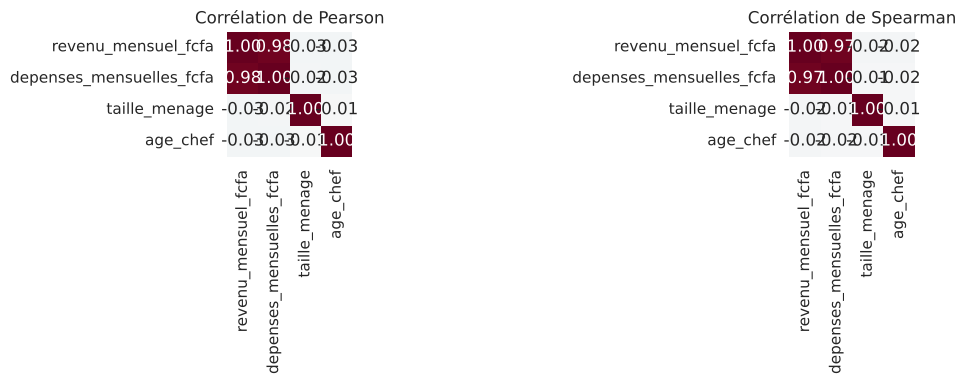

In [7]:
num = menages[["revenu_mensuel_fcfa", "depenses_mensuelles_fcfa", "taille_menage", "age_chef"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, methode in zip(axes, ["pearson", "spearman"]):
    sns.heatmap(num.corr(method=methode), annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="RdBu_r", ax=ax,
                square=True, cbar=False)
    ax.set_title(f"Corrélation de {methode.capitalize()}")
plt.tight_layout(); plt.show()

### ⚠️ Les pièges de la corrélation

1. **Corrélation ≠ causalité** (facteurs de confusion : le milieu urbain augmente *à la fois* l'accès à internet et le revenu).
2. Un $r$ proche de 0 **n'exclut pas** une relation **non linéaire**.
3. Le **quartet d'Anscombe** (1973) : quatre jeux avec la même moyenne, variance et $r$… et des formes totalement différentes.
   👉 **Toujours tracer les données.**

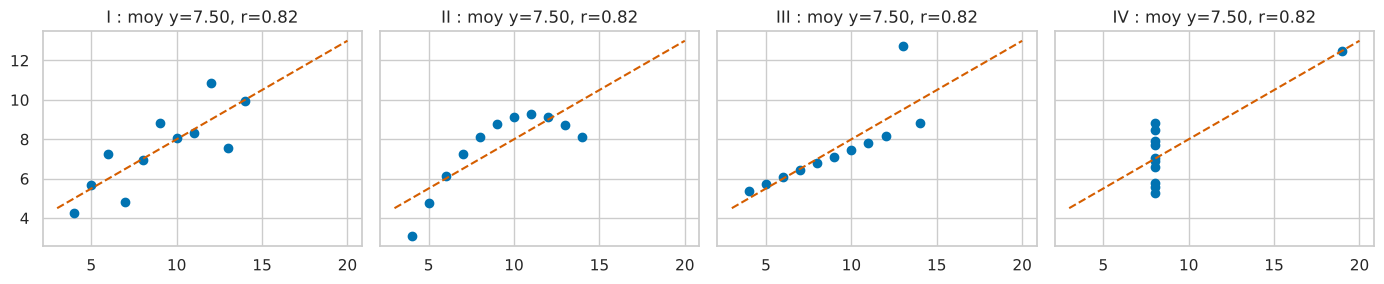

In [8]:
anscombe = {
    "I": ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
    "II": ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
    "III": ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
    "IV": ([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]),
}
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, (nom, (x, y)) in zip(axes, anscombe.items()):
    x, y = np.array(x), np.array(y)
    pente, origine = np.polyfit(x, y, 1)
    ax.scatter(x, y); ax.plot([3, 20], [origine + 3 * pente, origine + 20 * pente], "r--")
    ax.set_title(f"{nom} : moy y={y.mean():.2f}, r={np.corrcoef(x, y)[0, 1]:.2f}")
plt.tight_layout(); plt.show()

### 3.4 Qualitative × qualitative

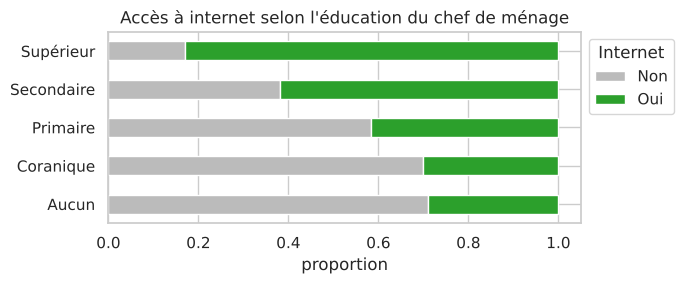

In [9]:
tab = pd.crosstab(menages["education_chef"], menages["acces_internet"], normalize="index")
ax = tab.plot(kind="barh", stacked=True, figsize=(7, 3), color=["#bbbbbb", "tab:green"])
ax.set(xlabel="proportion", ylabel="", title="Accès à internet selon l'éducation du chef de ménage")
ax.legend(title="Internet", bbox_to_anchor=(1, 1)); plt.tight_layout(); plt.show()

## 4. Multivarié : *facettes* et *pairplot*

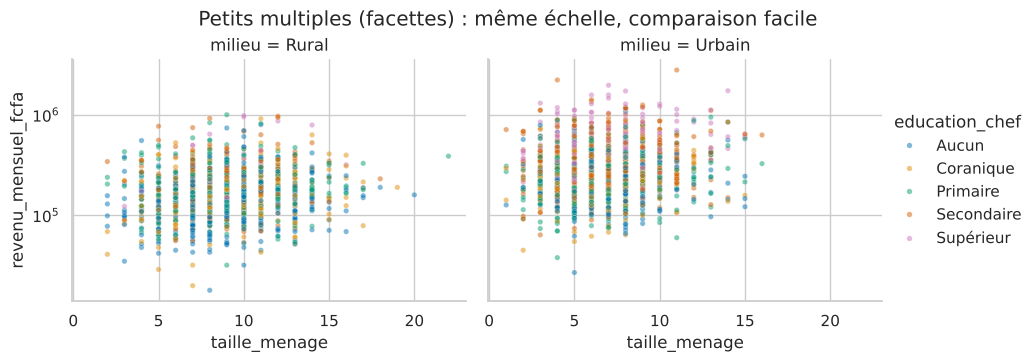

In [10]:
g = sns.relplot(data=menages.dropna(subset=["revenu_mensuel_fcfa"]), x="taille_menage", y="revenu_mensuel_fcfa",
                col="milieu", hue="education_chef", kind="scatter", alpha=0.5, s=15, height=3.5, aspect=1.3)
g.set(yscale="log"); g.figure.suptitle("Petits multiples (facettes) : même échelle, comparaison facile", y=1.03)
plt.show()

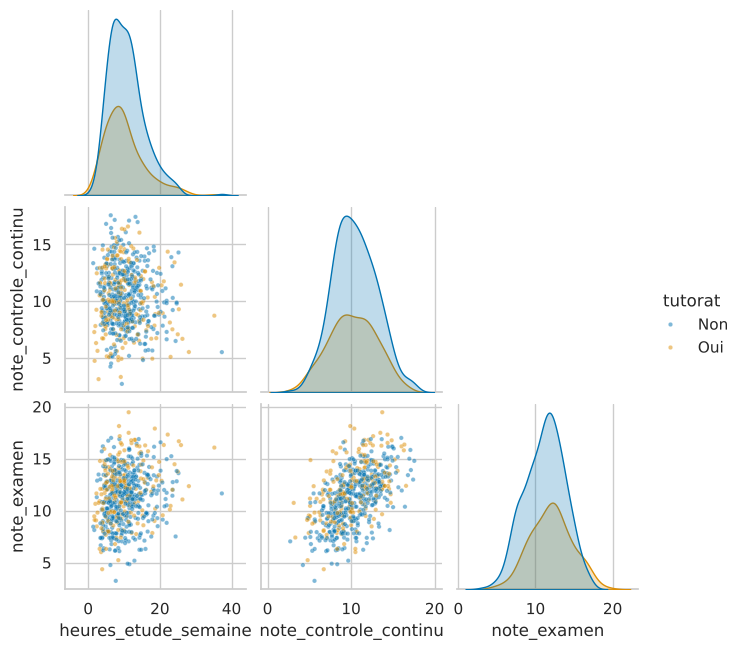

In [11]:
etudiants = pd.read_csv(DATA / "resultats_etudiants.csv")
sns.pairplot(etudiants, vars=["heures_etude_semaine", "note_controle_continu", "note_examen"], hue="tutorat",
             corner=True, plot_kws=dict(s=10, alpha=0.5), height=2.2)
plt.show()

## 5. Principes d'un bon graphique

1. **Un message par graphique**, écrit dans le **titre** (« Le revenu croît avec l'éducation », pas « Graphique 3 »).
2. **Axes étiquetés** avec **unités** ; échelle log signalée.
3. Les barres **commencent à zéro** (la longueur encode la valeur) ; une courbe peut ne pas commencer à zéro.
4. Pas de 3D, pas d'effets décoratifs (« *chartjunk* », Tufte) ; maximiser le ratio **données/encre**.
5. Couleurs **accessibles** (palettes `colorblind`, `viridis`) ; ne pas coder l'information **par la couleur seule**.
6. **Trier** les catégories nominales par valeur ; garder l'ordre naturel des ordinales.
7. Afficher l'**incertitude** (intervalles de confiance, chapitre 7) quand on compare des moyennes.

## 6. Checklist d'une EDA

- [ ] Dimensions, types, manquants, doublons (chap. 3)
- [ ] Chaque variable seule : distribution, valeurs extrêmes, modalités rares
- [ ] Variable cible vs chaque variable explicative
- [ ] Corrélations entre explicatives (redondances)
- [ ] Sous-groupes : le constat global tient-il dans chaque groupe ? (paradoxe de Simpson)
- [ ] Noter les **hypothèses** à tester (chap. 7) et les **transformations** à faire (chap. 8)

**Références** : Tukey J. W. (1977), *Exploratory Data Analysis* ; Tufte E. (2001), *The Visual Display of
Quantitative Information* ; Wilke C. (2019), *Fundamentals of Data Visualization* (en ligne : <https://clauswilke.com/dataviz/>) ;
Anscombe F. J. (1973), « Graphs in Statistical Analysis », *The American Statistician* 27(1).

➡️ **Chapitre suivant : statistique inférentielle.**